In [1]:
import numpy as np
import pandas as pd
import linearsolve as ls
import statsmodels.api as sm
import matplotlib.pyplot as plt
plt.style.use('classic')
%matplotlib inline

# Class 13: Introduction to Real Business Cycle Modeling

## Import Data

In [2]:
# Read rbc_data.csv into a Pandas DataFrame with the first column set as the index and parse_dates=True
df = pd.read_csv('https://raw.githubusercontent.com/letsgoexploring/computational-macroeconomics/master/Data/Csv/rbc_data_actual_trend_cycle.csv',index_col=0,parse_dates=True)

# Set base year
base_year = '2012'

## Estimate TFP Process

In [3]:
# Create a new column to df called tfp_cycle equal to the log difference between actual TFP and it's trend:
df['tfp_cycle'] = np.log(df['tfp']/df['tfp_trend'])

# Create a new column to df called tfp_cycle_lag that, for each date, contains values 
# in 'tfp_cycle' at the previous date
df['tfp_cycle_lag'] = df['tfp_cycle'].shift()

# Use dropna() method on df to remove the row iwth the missing value
df= df.dropna()

# Create variable 'X' to be the independent variable of the OLS model. Do not add a constant to X
X = df['tfp_cycle_lag']

# Create variable 'Y' to be the dependent variable of the OLS model.
Y = df['tfp_cycle']

# Create a variable called 'model' that initializes the OLS model
model = sm.OLS(Y,X)

# Create a variable called 'results' that stores the results of the estimated OLS model
results = model.fit()

# Print output of summary2() mdethod of results
print(results.summary2())

                        Results: Ordinary least squares
Model:                  OLS              Adj. R-squared (uncentered): 0.549     
Dependent Variable:     tfp_cycle        AIC:                         -2171.1302
Date:                   2022-10-25 14:44 BIC:                         -2167.4365
No. Observations:       297              Log-Likelihood:              1086.6    
Df Model:               1                F-statistic:                 362.8     
Df Residuals:           296              Prob (F-statistic):          2.35e-53  
R-squared (uncentered): 0.551            Scale:                       3.9020e-05
------------------------------------------------------------------------------------
                    Coef.      Std.Err.        t        P>|t|      [0.025     0.975]
------------------------------------------------------------------------------------
tfp_cycle_lag       0.7454       0.0391     19.0472     0.0000     0.6684     0.8225
-------------------------------------

## Stochastic Solow Model

### Solve the Model

In [4]:
# Input model parameters
parameters = pd.Series(dtype=float)
parameters['rho'] = rho = results.params['tfp_cycle_lag']
parameters['sigma_squared'] = results.resid.std()**2
parameters['alpha'] = 0.35
parameters['delta'] = 0.025
parameters['s'] = np.mean(df['investment']/df['gdp'])

# Create variable called 'var_names' that stores the variable names in a list with state variables ordered first
var_names = ['a','k','y','c','i']

# Create variable called 'shock_names' that stores an exogenous shock name for each state variable.
shock_names = ['e_a']

# Define a function that evaluates the equilibrium conditions. PROVIDED
def equilibrium_equations(variables_forward,variables_current,parameters):
    
    # Parameters. PROVIDED
    p = parameters
    
    # Current variables. PROVIDED
    cur = variables_current
    
    # Forward variables. PROVIDED
    fwd = variables_forward
        
    # Production function
    production_function = cur.a*cur.k**p.alpha - cur.y
    
    # Capital evolution
    capital_evolution = p.s*cur.a*cur.k**p.alpha + (1 - p.delta)*cur.k - fwd.k
    
    # Consumption function
    consumption_function = (1-p.s)*cur.y  - cur.c
    
    # Goods market clearing
    market_clearing = cur.i + cur.c - cur.y
    
    # Exogenous tfp
    tfp_process = p.rho*np.log(cur.a) - np.log(fwd.a)
    
    
    # Stack equilibrium conditions into a numpy array
    return np.array([
        production_function,
        capital_evolution,
        consumption_function,
        market_clearing,
        tfp_process
        ])

# Initialize the model. Note that state variables must be named first in the var_names argument
stoch_solow_model = ls.model(equations = equilibrium_equations,
                 n_states=2,
                 n_exo_states=1,
                 var_names=var_names,
                 shock_names=shock_names,
                 parameters = parameters)


# Compute the steady state numerically using linearsolve
guess = [1,4,1,1,1]
stoch_solow_model.compute_ss(guess)

# Print the computed steady state
print(stoch_solow_model.ss)

# Find the log-linear approximation around the non-stochastic steady state and solve
stoch_solow_model.approximate_and_solve()

a     1.000000
k    19.684411
y     2.837546
c     2.345435
i     0.492110
dtype: float64


### Simulate Data Using Estimated TFP Residuals

In [5]:
# Store estimated TFP shocks along with array of zeros to represent capital shocks.
epsilon = np.array([results.resid,np.zeros(len(results.resid))]).T

# Simulate Stochastic Solow growth model
simulated_data_solow = pd.DataFrame(ls.ir(stoch_solow_model.f,stoch_solow_model.p,epsilon).T,columns = ['tfp_cycle','capital_cycle','gdp_cycle','consumption_cycle','investment_cycle'],index=results.resid.index)

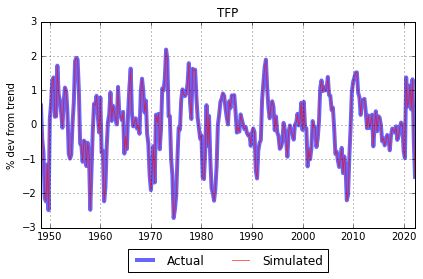

In [6]:
# Plot actual TFP and TFP simulated using estimated residuals.
fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(1,1,1)
ax1.plot(df['tfp_cycle']*100,'-',lw=4,alpha=0.6,label='Actual')
ax1.plot(simulated_data_solow['tfp_cycle']*100,'r-',lw=1,alpha=0.6,label='Simulated')
ax1.set_ylabel('% dev from trend')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.075),ncol=2)
ax1.grid()
ax1.set_title('TFP')

fig.tight_layout()

### Plots and Statistics

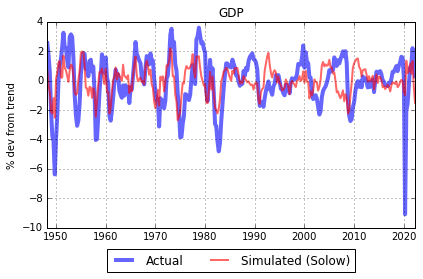

In [7]:
fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(1,1,1)
ax1.plot(df['gdp_cycle']*100,'-',lw=4,alpha=0.6,label='Actual')
ax1.plot(simulated_data_solow['gdp_cycle']*100,'r-',lw=2,alpha=0.6,label='Simulated (Solow)')
ax1.set_ylabel('% dev from trend')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.075),ncol=2)
ax1.grid()
ax1.set_title('GDP')

fig.tight_layout()

# Save image and make LaTex figure
figName = '013_intro_rbc_modeling_solow_gdp'
plt.savefig('fig_'+figName+'.png',bbox_inches='tight',dpi=120)

nf = open('figure_'+figName+'.tex', 'w')
nf.write('\\begin{figure}[h] \\caption{\\label{fig_'+figName+'} \\textbf{GDP.} The stochastic Solow growth model does a \emph{reasonably} good job matching GDP fluctuations for the US from '+df.index[0].strftime('%B %Y')+' to '+df.index[-1].strftime('%B %Y')+'. {\\tiny Source: FRED}.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\\includegraphics[height = 4.5cm]{fig_'+figName+'.png}\\end{center}\n')
nf.write('\\end{figure}')
nf.close()

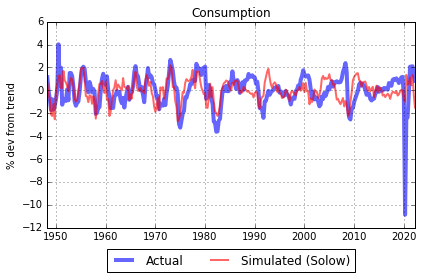

In [8]:
fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(1,1,1)
ax1.plot(df['consumption_cycle']*100,'-',lw=4,alpha=0.6,label='Actual')
ax1.plot(simulated_data_solow['consumption_cycle']*100,'r-',lw=2,alpha=0.6,label='Simulated (Solow)')
ax1.set_ylabel('% dev from trend')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.075),ncol=2)
ax1.grid()
ax1.set_title('Consumption')

fig.tight_layout()

# Save image and make LaTex figure
figName = '013_intro_rbc_modeling_solow_consumption'
plt.savefig('fig_'+figName+'.png',bbox_inches='tight',dpi=120)

nf = open('figure_'+figName+'.tex', 'w')
nf.write('\\begin{figure}[h] \\caption{\\label{fig_'+figName+'} \\textbf{Consumption.} The stochastic Solow growth model also does a \emph{reasonably} good job matching consumption fluctuations for the US from '+df.index[0].strftime('%B %Y')+' to '+df.index[-1].strftime('%B %Y')+'. {\\tiny Source: FRED}.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\\includegraphics[height = 4.5cm]{fig_'+figName+'.png}\\end{center}\n')
nf.write('\\end{figure}')
nf.close()

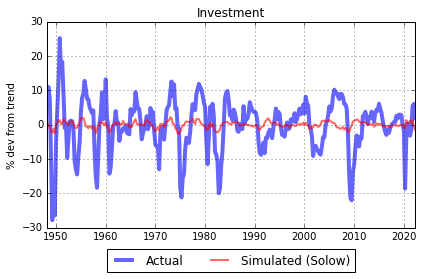

In [9]:
fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(1,1,1)
ax1.plot(df['investment_cycle']*100,'-',lw=4,alpha=0.6,label='Actual')
ax1.plot(simulated_data_solow['investment_cycle']*100,'r-',lw=2,alpha=0.6,label='Simulated (Solow)')
ax1.set_ylabel('% dev from trend')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.075),ncol=2)
ax1.grid()
ax1.set_title('Investment')

fig.tight_layout()

# Save image and make LaTex figure
figName = '013_intro_rbc_modeling_solow_investment'
plt.savefig('fig_'+figName+'.png',bbox_inches='tight',dpi=120)

nf = open('figure_'+figName+'.tex', 'w')
nf.write('\\begin{figure}[h] \\caption{\\label{fig_'+figName+'} \\textbf{Investment.} The stochastic Solow growth model \emph{under-predicts} the magnitude of investment fluctuations for the US from '+df.index[0].strftime('%B %Y')+' to '+df.index[-1].strftime('%B %Y')+'. {\\tiny Source: FRED}.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\\includegraphics[height = 4.5cm]{fig_'+figName+'.png}\\end{center}\n')
nf.write('\\end{figure}')
nf.close()

In [10]:
# Construct DataFrame of standard deviations
stds_df = pd.DataFrame({
    'Actual Data':df[['gdp_cycle','consumption_cycle','investment_cycle']].std().round(4).values,
    'Simulated Data (Solow)':simulated_data_solow[['gdp_cycle','consumption_cycle','investment_cycle']].std().round(4).values
},index=['Output','Consumption','Investment'])

stds_df = stds_df*100

# Construct LaTeX table
tabName = '013_intro_rbc_modeling_solow_stds'

nf = open('table_'+tabName+'.tex', 'w')
nf.write('\\begin{table}[h] \\caption{\\label{tab'+tabName+'} \\textbf{Standard deviations.} Actual data and data simulated from stochastic Solow model. Units are percent deviations from trend. The model \
under-predicts the volatility of investment in particular. {\\tiny Source: FRED}.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\n\n'+stds_df.to_latex(column_format='lcc')+'\\end{center}\n')
nf.write('\\end{table}')
nf.close()

# Show standard deviations
stds_df

/var/folders/36/tyk09l294j7b2stxnfxym2200000gp/T/ipykernel_6612/114569650.py:15: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  nf.write('\\begin{center}\\hspace*{-.5cm}\n\n'+stds_df.to_latex(column_format='lcc')+'\\end{center}\n')


,Actual Data,Simulated Data (Solow)
Output,1.69,0.93
Consumption,1.34,0.93
Investment,7.41,0.93


In [11]:
# Construct DataFrame of correlations
corrs_df = pd.DataFrame({
    'Actual Data':df[['gdp_cycle','consumption_cycle','investment_cycle']].corr()['gdp_cycle'].round(2).values,
    'Simulated Data (Solow)':simulated_data_solow[['gdp_cycle','consumption_cycle','investment_cycle']].corr()['gdp_cycle'].round(2).values
},index=['Output','Consumption','Investment'])

corrs_df = corrs_df.loc[['Consumption','Investment']]

# Construct LaTeX table
tabName = '013_intro_rbc_modeling_solow_corrs'

nf = open('table_'+tabName+'.tex', 'w')
nf.write('\\begin{table}[h] \\caption{\\label{tab'+tabName+'} \\textbf{Correlations with GDP.} Actual data and data simulated from stochastic Solow model. The model \
over-predicts the correlation of investment and consumption with GDP. {\\tiny Source: FRED}.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\n\n'+corrs_df.to_latex(column_format='lcc')+'\\end{center}\n')
nf.write('\\end{table}')
nf.close()

# Show correlations
corrs_df

/var/folders/36/tyk09l294j7b2stxnfxym2200000gp/T/ipykernel_6612/1249996017.py:15: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  nf.write('\\begin{center}\\hspace*{-.5cm}\n\n'+corrs_df.to_latex(column_format='lcc')+'\\end{center}\n')


,Actual Data,Simulated Data (Solow)
Consumption,0.81,1.0
Investment,0.84,1.0


## Baseline RBC Model Without Labor

### Solve the Model

In [12]:
# Input model parameters
parameters = pd.Series(dtype=float)
parameters['rho'] = rho = results.params['tfp_cycle_lag']
parameters['sigma_squared'] = results.resid.std()**2
parameters['alpha'] = 0.35
parameters['delta'] = 0.025
parameters['beta'] = 0.99
parameters['s'] = np.mean(df['investment']/df['gdp'])

# Create variable called 'var_names' that stores the variable names in a list with state variables ordered first
var_names = ['a','k','y','c','i']

# Create variable called 'shock_names' that stores an exogenous shock name for each state variable.
shock_names = ['e_a']

# Define a function that evaluates the equilibrium conditions. PROVIDED
def equilibrium_equations(variables_forward,variables_current,parameters):
    
    # Parameters. PROVIDED
    p = parameters
    
    # Current variables. PROVIDED
    cur = variables_current
    
    # Forward variables. PROVIDED
    fwd = variables_forward
        
    # Production function
    production_function = cur.a*cur.k**p.alpha - cur.y
    
    # Capital evolution
    capital_evolution = cur.i + (1 - p.delta)*cur.k - fwd.k
    
    # Consumption function
    euler_equation = p.beta/fwd.c*(p.alpha*fwd.a*fwd.k**(p.alpha-1)+1-p.delta) - 1/cur.c
    
    # Goods market clearing
    market_clearing = cur.i + cur.c - cur.y
    
    # Exogenous tfp
    tfp_process = p.rho*np.log(cur.a) - np.log(fwd.a)
    
    
    # Stack equilibrium conditions into a numpy array
    return np.array([
        production_function,
        capital_evolution,
        euler_equation,
        market_clearing,
        tfp_process
        ])

# Initialize the model. Note that state variables must be named first in the var_names argument
rbc_model = ls.model(equations = equilibrium_equations,
                 n_states=2,
                 n_exo_states=1,
                 var_names=var_names,
                 shock_names=shock_names,
                 parameters = parameters)


# Compute the steady state numerically using linearsolve
guess = [1,10,1,1,1]
rbc_model.compute_ss(guess)

# Find the log-linear approximation around the non-stochastic steady state and solve
rbc_model.approximate_and_solve()

rbc_model.parameters

rho              0.745448
sigma_squared    0.000039
alpha            0.350000
delta            0.025000
beta             0.990000
s                0.173428
dtype: float64

### Simulate Data Using Estimated TFP Residuals

In [13]:
# Store estimated TFP shocks along with array of zeros to represent capital shocks.
epsilon = np.array([results.resid,np.zeros(len(results.resid))]).T

# Simulate RBC model without labor
simulated_data_rbc = pd.DataFrame(ls.ir(rbc_model.f,rbc_model.p,epsilon).T,columns = ['tfp_cycle','capital_cycle','gdp_cycle','consumption_cycle','investment_cycle'],index=results.resid.index)


### Impulse Responses

In [14]:
# Compute impulse responses to a 0.01 unit shock to each state variable.
rbc_model.impulse(T=26,t0=5)

### Plots and Statistics

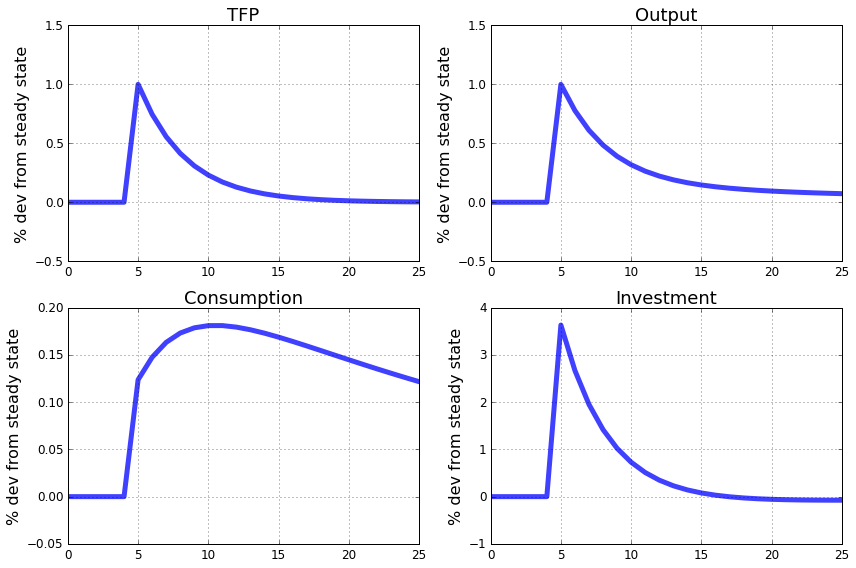

In [15]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(2,2,1)
ax.plot(rbc_model.irs['e_a']['a']*100,'b',lw=5,alpha=0.75)
ax.set_title('TFP',fontsize=18)
ax.set_ylabel('% dev from steady state',fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_ylim([-0.5,1.5])
ax.grid()

ax = fig.add_subplot(2,2,2)
ax.plot(rbc_model.irs['e_a']['y']*100,'b',lw=5,alpha=0.75)
ax.set_title('Output',fontsize=18)
ax.set_ylabel('% dev from steady state',fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_ylim([-0.5,1.5])
ax.grid()

ax = fig.add_subplot(2,2,3)
ax.plot(rbc_model.irs['e_a']['c']*100,'b',lw=5,alpha=0.75)
ax.set_title('Consumption',fontsize=18)
ax.set_ylabel('% dev from steady state',fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_ylim([-0.05,0.2])
ax.grid()

ax = fig.add_subplot(2,2,4)
ax.plot(rbc_model.irs['e_a']['i']*100,'b',lw=5,alpha=0.75)
ax.set_title('Investment',fontsize=18)
ax.set_ylabel('% dev from steady state',fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_ylim([-1,4])
ax.grid()

fig.tight_layout()


# Save image and make LaTex figure
figName = '013_intro_rbc_modeling_rbc_without_labor_irs'
plt.savefig('fig_'+figName+'.png',bbox_inches='tight',dpi=120)

nf = open('figure_'+figName+'.tex', 'w')
nf.write('\\begin{figure}[h] \\caption{\\label{fig_'+figName+'} \\textbf{Baseline RBC model without labor.} Impulse responses to a one percent shock to TFP in period 5.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\\includegraphics[height = 4.5cm]{fig_'+figName+'.png}\\end{center}\n')
nf.write('\\end{figure}')
nf.close()

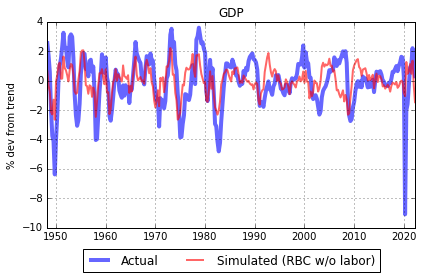

In [16]:
fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(1,1,1)
ax1.plot(df['gdp_cycle']*100,'-',lw=4,alpha=0.6,label='Actual')
ax1.plot(simulated_data_rbc['gdp_cycle']*100,'r-',lw=2,alpha=0.6,label='Simulated (RBC w/o labor)')
ax1.set_ylabel('% dev from trend')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.075),ncol=2)
ax1.grid()
ax1.set_title('GDP')

fig.tight_layout()

# Save image and make LaTex figure
figName = '013_intro_rbc_modeling_rbc_without_labor_gdp'
plt.savefig('fig_'+figName+'.png',bbox_inches='tight',dpi=120)

nf = open('figure_'+figName+'.tex', 'w')
nf.write('\\begin{figure}[h] \\caption{\\label{fig_'+figName+'} \\textbf{GDP.} Like the stochastic Solow model, the baseline RBC model without labor does a \emph{reasonably} good job matching GDP fluctuations for the US. {\\tiny Source: FRED}.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\\includegraphics[height = 4.5cm]{fig_'+figName+'.png}\\end{center}\n')
nf.write('\\end{figure}')
nf.close()

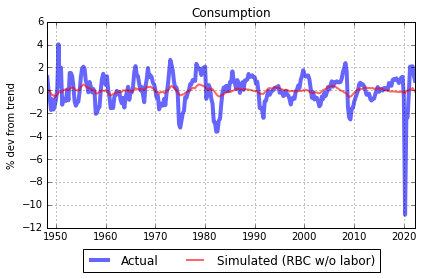

In [17]:
fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(1,1,1)
ax1.plot(df['consumption_cycle']*100,'-',lw=4,alpha=0.6,label='Actual')
ax1.plot(simulated_data_rbc['consumption_cycle']*100,'r-',lw=2,alpha=0.6,label='Simulated (RBC w/o labor)')
ax1.set_ylabel('% dev from trend')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.075),ncol=2)
ax1.grid()
ax1.set_title('Consumption')

fig.tight_layout()

# Save image and make LaTex figure
figName = '013_intro_rbc_modeling_rbc_without_labor_consumption'
plt.savefig('fig_'+figName+'.png',bbox_inches='tight',dpi=120)

nf = open('figure_'+figName+'.tex', 'w')
nf.write('\\begin{figure}[h] \\caption{\\label{fig_'+figName+'} \\textbf{Consumption.} In contrast to the stochastic Solow model, the baseline RBC model without labor \emph{under-predicts} the magnitude of consumption fluctuations for the US. {\\tiny Source: FRED}.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\\includegraphics[height = 4.5cm]{fig_'+figName+'.png}\\end{center}\n')
nf.write('\\end{figure}')
nf.close()

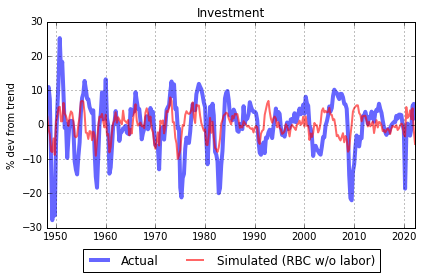

In [18]:
fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(1,1,1)
ax1.plot(df['investment_cycle']*100,'-',lw=4,alpha=0.6,label='Actual')
ax1.plot(simulated_data_rbc['investment_cycle']*100,'r-',lw=2,alpha=0.6,label='Simulated (RBC w/o labor)')
ax1.set_ylabel('% dev from trend')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.075),ncol=2)
ax1.grid()
ax1.set_title('Investment')

fig.tight_layout()

# Save image and make LaTex figure
figName = '013_intro_rbc_modeling_rbc_without_labor_investment'
plt.savefig('fig_'+figName+'.png',bbox_inches='tight',dpi=120)

nf = open('figure_'+figName+'.tex', 'w')
nf.write('\\begin{figure}[h] \\caption{\\label{fig_'+figName+'} \\textbf{Investment.} The baseline RBC model does a \emph{reasonably} good job matching the magnitude of investment fluctuations better than the stochastic Solow model. {\\tiny Source: FRED}.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\\includegraphics[height = 4.5cm]{fig_'+figName+'.png}\\end{center}\n')
nf.write('\\end{figure}')
nf.close()

In [19]:
# Construct DataFrame of standard deviations
stds_df = pd.DataFrame({
    'Actual Data':df[['gdp_cycle','consumption_cycle','investment_cycle']].std().round(4).values,
    'Solow':simulated_data_solow[['gdp_cycle','consumption_cycle','investment_cycle']].std().round(4).values,
    'RBC w/o Labor':simulated_data_rbc[['gdp_cycle','consumption_cycle','investment_cycle']].std().round(4).values
},index=['Output','Consumption','Investment'])

stds_df = stds_df*100

# Construct LaTeX table
tabName = '013_intro_rbc_modeling_solow_rbc_without_labor_stds'

nf = open('table_'+tabName+'.tex', 'w')
nf.write('\\begin{table}[h] \\caption{\\label{tab'+tabName+'} \\textbf{Standard deviations.} Actual data and simulated data. Units are percent deviations from trend. {\\tiny Source: FRED}.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\n\n'+stds_df.to_latex(column_format='lccc')+'\\end{center}\n')
nf.write('\\end{table}')
nf.close()

# Show standard deviations
stds_df

/var/folders/36/tyk09l294j7b2stxnfxym2200000gp/T/ipykernel_6612/3410237894.py:15: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  nf.write('\\begin{center}\\hspace*{-.5cm}\n\n'+stds_df.to_latex(column_format='lccc')+'\\end{center}\n')


,Actual Data,Solow,RBC w/o Labor
Output,1.69,0.93,0.94
Consumption,1.34,0.93,0.22
Investment,7.41,0.93,3.39


In [20]:
# Construct DataFrame of correlations
corrs_df = pd.DataFrame({
    'Actual Data':df[['gdp_cycle','consumption_cycle','investment_cycle']].corr()['gdp_cycle'].round(2).values,
    'Solow':simulated_data_solow[['gdp_cycle','consumption_cycle','investment_cycle']].corr()['gdp_cycle'].round(2).values,
    'RBC w/o Labor':simulated_data_rbc[['gdp_cycle','consumption_cycle','investment_cycle']].corr()['gdp_cycle'].round(2).values
},index=['Output','Consumption','Investment'])

corrs_df = corrs_df.loc[['Consumption','Investment']]

# Construct LaTeX table
tabName = '013_intro_rbc_modeling_solow_rbc_without_labor_corrs'

nf = open('table_'+tabName+'.tex', 'w')
nf.write('\\begin{table}[h] \\caption{\\label{tab'+tabName+'} \\textbf{Correlations with GDP.} Actual data and simulated data. {\\tiny Source: FRED}.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\n\n'+corrs_df.to_latex(column_format='lccc')+'\\end{center}\n')
nf.write('\\end{table}')
nf.close()

# Show correlations
corrs_df

/var/folders/36/tyk09l294j7b2stxnfxym2200000gp/T/ipykernel_6612/288902629.py:15: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  nf.write('\\begin{center}\\hspace*{-.5cm}\n\n'+corrs_df.to_latex(column_format='lccc')+'\\end{center}\n')


,Actual Data,Solow,RBC w/o Labor
Consumption,0.81,1.0,0.61
Investment,0.84,1.0,0.99
